# Check FER backbone

## Purpose
- Check if the FER backbone is correctly loaded and functional.

## Checkpoints
- 权重能不能加载、embedding 维度是多少、情绪类别是几类；
- 模型对一张真实人脸图输出什么（含输入预览，用来抓 BGR/RGB 与 crop 错误）；
- 在批量人脸上情绪概率的分布是否几乎全是 Neutral（plan §6.2 要求记录的指标）；
- ImageNet 对照臂是否与 FER 臂同架构（H3/A2 干净对照的前提）；
- 部分微调通路是否通（只解冻最后一个 block，梯度是否落在预期参数上）。

## Requirements check

In [2]:
import importlib.util as _u
import sys

REQUIRED = ['torch', 'torchvision', 'timm', 'emotiefflib', 'numpy', 'pandas', 'matplotlib', 'PIL']
missing = [m for m in REQUIRED if _u.find_spec(m) is None]
print('python', sys.version.split()[0])
if missing:
    print('缺失依赖:', ', '.join(missing))
    print('请先安装: pip install torch torchvision "emotiefflib[torch]" matplotlib pandas scikit-learn')
    print('(emotiefflib[torch] 会自动安装 timm==0.9.*；已核实 v1.1.1 的 extras: torch / engagement / all)')
else:
    import torch, timm
    print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
    print('timm ', timm.__version__)
    if not timm.__version__.startswith('0.9'):
        print('警告: 权重是 timm 0.9.x 序列化的，其他版本可能加载失败')

python 3.12.6


c:\Users\74674\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.7.0+cu118 | cuda available: True
timm  0.9.16


## Setup

In [3]:
from pathlib import Path

# —— 唯一需要手改的地方 ——
MODEL_NAME = 'enet_b0_8_best_vgaf'   # 备选: enet_b0_8_best_afew / enet_b2_8 / enet_b2_7
ENGINE     = 'torch'                 # 固定 torch：ONNX 引擎无法微调，且颜色通道处理不同
DEVICE     = 'cuda'                  # 没有 GPU 就改 'cpu'
IMAGENET_CONTROL = 'efficientnet_b0' # ImageNet 对照臂；b0 对应 enet_b0_*, b2 对应 enet_b2_*

# 项目根目录：向上找到含 README.md 的目录，notebook 放在 notebooks/ 下也能跑
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / 'README.md').exists() and (cand / 'docs' / 'plan.md').exists():
            return cand
    return p

PROJECT_ROOT = find_project_root()
FACE_DIR   = PROJECT_ROOT / 'data' / 'faces'      # gitignored，放已选定的人脸 crop
OUT_TABLES = PROJECT_ROOT / 'results' / 'tables'
OUT_FIGS   = PROJECT_ROOT / 'results' / 'figures'
OUT_REPORTS= PROJECT_ROOT / 'results' / 'reports'
for d in (OUT_TABLES, OUT_FIGS, OUT_REPORTS):
    d.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('MODEL_NAME   =', MODEL_NAME, '| DEVICE =', DEVICE)

PROJECT_ROOT = C:\Users\74674\Desktop\2012 DeepLearning\Project\Penalty-shoot-and-Expression
MODEL_NAME   = enet_b0_8_best_vgaf | DEVICE = cuda


## Test

In [4]:
import numpy as np
from PIL import Image, ImageDraw

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_faces(face_dir=FACE_DIR, limit=None):
    if not face_dir.exists():
        return []
    files = sorted(f for f in face_dir.rglob('*') if f.suffix.lower() in IMG_EXT)
    return files[:limit] if limit else files

def load_rgb(path):
    # 统一转 RGB：EmotiEffLib 的 torch 引擎内部走 PIL，按 RGB 解释数组
    return np.asarray(Image.open(path).convert('RGB'))

def synthetic_face(size=224):
    # 占位图：只能验证通路，不能验证领域分布
    img = Image.new('RGB', (size, size), (230, 200, 180))
    d = ImageDraw.Draw(img)
    d.ellipse([size*0.2, size*0.15, size*0.8, size*0.85], fill=(235, 205, 185))
    d.ellipse([size*0.33, size*0.38, size*0.42, size*0.47], fill=(40, 40, 40))
    d.ellipse([size*0.58, size*0.38, size*0.67, size*0.47], fill=(40, 40, 40))
    d.arc([size*0.36, size*0.55, size*0.64, size*0.75], start=0, end=180, fill=(120, 60, 60), width=4)
    return np.asarray(img)

FACES = list_faces()
USE_SYNTHETIC = len(FACES) == 0
face_arrays = [synthetic_face()] if USE_SYNTHETIC else [load_rgb(p) for p in FACES]
print('找到人脸图', len(FACES), '张 ->', FACE_DIR)
if USE_SYNTHETIC:
    print('!! 未找到真实人脸，使用合成占位图：只验证加载/维度/微调通路，情绪分布结论无效')
    print('   把 pilot 选定的人脸 crop 放进 data/faces/ 后重跑本 notebook 即可得到有意义的分布')

找到人脸图 114 张 -> C:\Users\74674\Desktop\2012 DeepLearning\Project\Penalty-shoot-and-Expression\data\faces


## Encoder

In [5]:
from emotiefflib.facial_analysis import EmotiEffLibRecognizer, get_model_list

print('可选权重:', get_model_list())
fer = EmotiEffLibRecognizer(engine=ENGINE, model_name=MODEL_NAME, device=DEVICE)

probe = fer.extract_features(face_arrays[:1])
EMB_DIM = int(probe.shape[-1])
N_EMOTION = len(fer.idx_to_emotion_class)

print('engine      :', ENGINE)
print('model       :', MODEL_NAME)
print('img_size    :', fer.img_size, '| mean/std:', fer.mean, fer.std)
print('embedding   :', EMB_DIM, '维')
print('emotions    :', N_EMOTION, '类 ->', list(fer.idx_to_emotion_class.values()))
print('head weight :', fer.classifier_weights.shape)
# 一致性自检：分类头输入维度必须等于 embedding 维度
assert fer.classifier_weights.shape[1] == EMB_DIM, '分类头维度与 embedding 不一致'
assert N_EMOTION in (7, 8), f'意外的情绪类别数: {N_EMOTION}'
print('OK: 分类头与 embedding 维度自洽')

可选权重: ['enet_b0_8_best_vgaf', 'enet_b0_8_best_afew', 'enet_b2_8', 'enet_b0_8_va_mtl', 'enet_b2_7', 'mbf_va_mtl', 'mobilevit_va_mtl']
engine      : torch
model       : enet_b0_8_best_vgaf
img_size    : 224 | mean/std: [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]
embedding   : 1280 维
emotions    : 8 类 -> ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
head weight : (8, 1280)
OK: 分类头与 embedding 维度自洽


## Smoke test

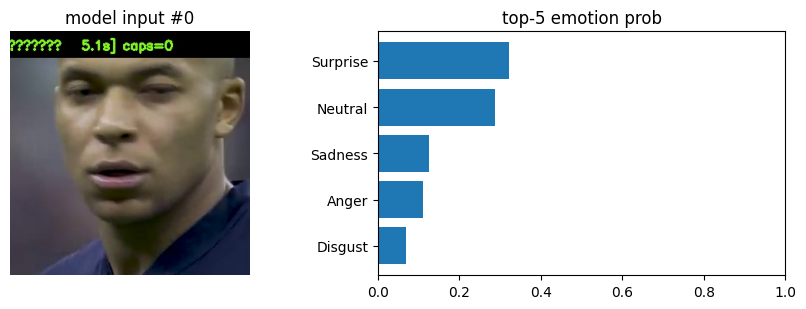

预测标签: Surprise
概率和  : 1.0 (应≈1)
  Surprise   0.3211
  Neutral    0.2882
  Sadness    0.1256


In [6]:
import matplotlib.pyplot as plt

feats = fer.extract_features(face_arrays)
labels, probs = fer.classify_emotions(feats, logits=False)
EMO_NAMES = list(fer.idx_to_emotion_class.values())

i = 0
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].imshow(face_arrays[i]); axes[0].set_title('model input #0'); axes[0].axis('off')
order = np.argsort(probs[i])[::-1][:5]
axes[1].barh([EMO_NAMES[j] for j in order][::-1], [probs[i][j] for j in order][::-1])
axes[1].set_xlim(0, 1); axes[1].set_title('top-5 emotion prob')
plt.tight_layout(); plt.show()

print('预测标签:', labels[i])
print('概率和  :', round(float(probs[i].sum()), 6), '(应≈1)')
for j in order[:3]:
    print(f'  {EMO_NAMES[j]:10s} {probs[i][j]:.4f}')

## Emotion distribution on batch of faces

In [7]:
import pandas as pd

# 这里用的就是后面 scripts/cache_fer_features.py 的同一条前向路径，只是不落 embedding 缓存
probs_df = pd.DataFrame(probs, columns=EMO_NAMES)
probs_df.insert(0, 'path', [str(p) for p in FACES] or ['<synthetic>'])
argmax = probs_df[EMO_NAMES].values.argmax(axis=1)
probs_df['pred'] = [EMO_NAMES[k] for k in argmax]
probs_df['max_prob'] = probs_df[EMO_NAMES].values.max(axis=1)

print('样本数:', len(probs_df))
print()
print('— 预测标签分布 —')
print(probs_df['pred'].value_counts().to_string())
print()
print('— 各情绪平均概率 —')
print(probs_df[EMO_NAMES].mean().round(4).to_string())
print()
print(f"平均 max_prob = {probs_df['max_prob'].mean():.3f}  (越接近 1 说明模型越'自信'，未经校准不必然可信)")
if 'Neutral' in EMO_NAMES:
    share = float((probs_df['pred'] == 'Neutral').mean())
    print(f"预测为 Neutral 的比例 = {share:.1%}")
    if share > 0.8:
        print('  -> 预期之内：AffectNet 训练集大量接近面无表情，转播画面多为紧张/专注的扑克脸')
        print('  -> 这正是 H2(embedding vs 情绪概率) 的动机；不要因此直接放弃，先看 embedding 分支')

样本数: 114

— 预测标签分布 —
pred
Anger       65
Neutral     18
Sadness     16
Surprise     7
Contempt     4
Disgust      3
Fear         1

— 各情绪平均概率 —
Anger        0.4203
Contempt     0.0532
Disgust      0.0544
Fear         0.0320
Happiness    0.0162
Neutral      0.1950
Sadness      0.1750
Surprise     0.0539

平均 max_prob = 0.541  (越接近 1 说明模型越'自信'，未经校准不必然可信)
预测为 Neutral 的比例 = 15.8%


## Picture + Save

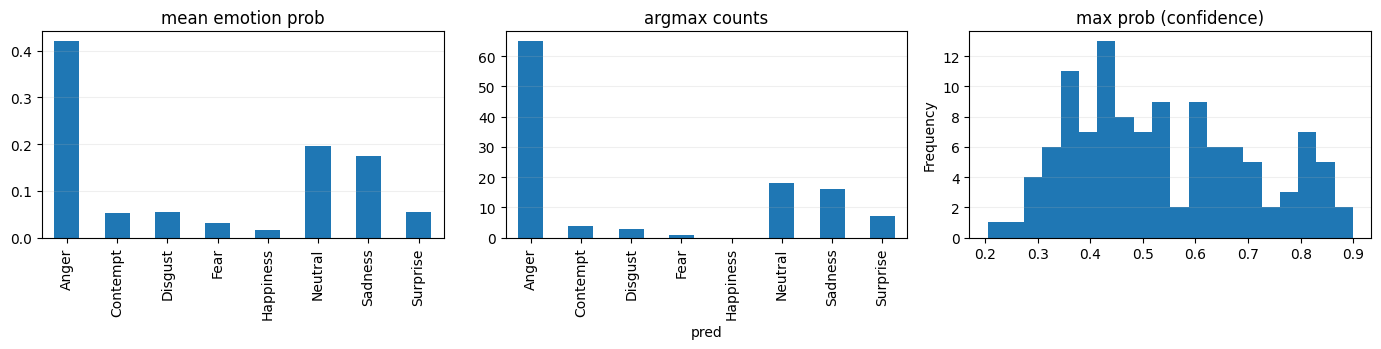

已保存: C:\Users\74674\Desktop\2012 DeepLearning\Project\Penalty-shoot-and-Expression\results\figures\fer_probe_enet_b0_8_best_vgaf.png
已保存: C:\Users\74674\Desktop\2012 DeepLearning\Project\Penalty-shoot-and-Expression\results\tables\fer_probe_enet_b0_8_best_vgaf.csv


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
probs_df[EMO_NAMES].mean().plot.bar(ax=axes[0], title='mean emotion prob')
probs_df['pred'].value_counts().reindex(EMO_NAMES).fillna(0).plot.bar(ax=axes[1], title='argmax counts')
probs_df['max_prob'].plot.hist(bins=20, ax=axes[2], title='max prob (confidence)')
for ax in axes: ax.grid(alpha=.2, axis='y')
plt.tight_layout()
fig_path = OUT_FIGS / f'fer_probe_{MODEL_NAME}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight'); plt.show()

csv_path = OUT_TABLES / f'fer_probe_{MODEL_NAME}.csv'
probs_df.to_csv(csv_path, index=False)
print('已保存:', fig_path)
print('已保存:', csv_path)

## ImageNet vs FER comparison

In [9]:
# H3/A2 要求：只改预训练来源，骨干规模与下游分类器尽量一致。
# EmotiEffLib 的 enet_* 骨干就是 timm 的 EfficientNet -> ImageNet 对照臂可用同架构 timm 权重
try:
    import timm, torch
    ctrl = timm.create_model(IMAGENET_CONTROL, pretrained=True, num_classes=0)  # 特征提取臂，去掉分类头
    ctrl.eval()
    n_fer  = sum(p.numel() for p in fer.model.parameters())
    n_ctrl = sum(p.numel() for p in ctrl.parameters())
    with torch.no_grad():
        ctrl_out = ctrl(torch.zeros(1, 3, fer.img_size, fer.img_size))
    print('FER  臂 backbone :', type(fer.model).__name__, f'| {n_fer/1e6:.2f}M params')
    print('ImageNet 对照臂  :', type(ctrl).__name__, f'| {n_ctrl/1e6:.2f}M params')
    print('对照臂输出维度   :', int(ctrl_out.shape[-1]))
    print('两臂参数量是否接近:', abs(n_fer - n_ctrl) / max(n_fer, 1) < 0.05)
    print('两臂输出维度是否一致:', int(ctrl_out.shape[-1]) == EMB_DIM)
except Exception as e:
    print('对照臂加载失败(离线/无权重缓存?):', type(e).__name__, e)

'[WinError 10054] 远程主机强迫关闭了一个现有的连接。' thrown while requesting HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].


对照臂加载失败(离线/无权重缓存?): RuntimeError Cannot send a request, as the client has been closed.


## Fine tuning test

In [10]:
# 对应 plan §8 Stage 2：只解冻 FER encoder 的最后一个 block，head 用更大学习率
import torch.nn as nn
from torchvision import transforms

def build_finetunable(fer, emb_dim, unfreeze_last_block=True, freeze_bn=True):
    enc = fer.model
    for p in enc.parameters():
        p.requires_grad = False
    if unfreeze_last_block and hasattr(enc, 'blocks'):
        for p in enc.blocks[-1].parameters():
            p.requires_grad = True
    if freeze_bn:
        # 小 batch 下 BN running stats 很不稳定 -> 冻结在 eval 行为
        for m in enc.modules():
            if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
                m.eval()
                for p in m.parameters():
                    p.requires_grad = False
    head = nn.Sequential(nn.Dropout(0.3), nn.Linear(emb_dim, 1))
    return enc, head

# 显式预处理（RGB + resize 到 img_size + fer.mean/std 归一化），不依赖 fer._preprocess 私有 API。
# 数值上与库内实现对齐即可：本 cell 只验证梯度通路，不比较情绪输出。
_size = (fer.img_size, fer.img_size) if isinstance(fer.img_size, int) else tuple(fer.img_size)
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(_size),
    transforms.ToTensor(),
    transforms.Normalize([float(v) for v in fer.mean], [float(v) for v in fer.std]),
])

def forward_features(enc, x):
    # fer.model 可能是纯特征骨干（输出 EMB_DIM），也可能带情绪分类头（输出类别数）
    out = enc(x)
    if out.shape[-1] == EMB_DIM:
        return out
    if hasattr(enc, 'forward_features'):
        return enc.forward_features(x)
    raise RuntimeError(
        f'enc(x) 输出 {tuple(out.shape)} 既不是 embedding 维度 {EMB_DIM}，'
        '也没有 forward_features；请查当前 emotiefflib 版本的特征前向入口')

enc, head = build_finetunable(fer, EMB_DIM)
head.to(DEVICE)
trainable = [(n, p.numel()) for n, p in list(enc.named_parameters()) + list(head.named_parameters()) if p.requires_grad]
total = sum(p.numel() for p in enc.parameters()) + sum(p.numel() for p in head.parameters())
n_train = sum(n for _, n in trainable)
print(f'可训练参数 {n_train/1e6:.3f}M / 总 {total/1e6:.3f}M = {n_train/total:.1%}')
print('解冻的编码器参数块:')
for n, sz in trainable[:8]:
    print(f'  {n:60s} {sz/1e3:.1f}K')

# 一次前向 + 反向，确认梯度只落在预期地方。
# 注意：encoder 全程保持 eval（BN 与 drop_path 冻结在推理行为），只把 head 切到 train；
# 调 enc.train() 会递归把 BN 设回 train 模式，撤销上面的冻结，是常见错误。
batch = face_arrays[:2]
x = torch.stack([preprocess(a) for a in batch]).to(DEVICE)
y = torch.tensor([[float(i % 2)] for i in range(len(batch))], device=DEVICE)  # 标签值无意义，只验证通路
head.train()
feats = forward_features(enc, x).flatten(1)
assert feats.shape[-1] == EMB_DIM, f'特征维度 {tuple(feats.shape)} 与 head 输入 {EMB_DIM} 不符'
logits = head(feats)
loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
loss.backward()
grad_ok = sum(1 for _, p in enc.named_parameters() if p.grad is not None)
grad_frozen = sum(1 for _, p in enc.named_parameters() if p.requires_grad is False and p.grad is not None)
print('loss =', float(loss))
print('有梯度的参数张量数:', grad_ok, '| 冻结却出现梯度的张量数:', grad_frozen, '(应为 0)')
assert grad_frozen == 0, '冻结参数出现了梯度，检查冻结逻辑'
print('OK: 部分微调通路可用（loss 来源是随机 head，数值本身无意义）')

可训练参数 0.713M / 总 4.009M = 17.8%
解冻的编码器参数块:
  blocks.6.0.conv_pw.weight                                    221.2K
  blocks.6.0.conv_dw.weight                                    10.4K
  blocks.6.0.se.conv_reduce.weight                             55.3K
  blocks.6.0.se.conv_reduce.bias                               0.0K
  blocks.6.0.se.conv_expand.weight                             55.3K
  blocks.6.0.se.conv_expand.bias                               1.2K
  blocks.6.0.conv_pwl.weight                                   368.6K
  1.weight                                                     1.3K
loss = 0.7169531583786011
有梯度的参数张量数: 7 | 冻结却出现梯度的张量数: 0 (应为 0)
OK: 部分微调通路可用（loss 来源是随机 head，数值本身无意义）


## Report JSON

In [11]:
import json, datetime

summary = {
    'checked_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'fer_backbone': {
        'library': 'emotiefflib',
        'model_name': MODEL_NAME,
        'engine': ENGINE,
        'backbone_class': type(fer.model).__name__,
        'img_size': int(fer.img_size),
        'embedding_dim': int(EMB_DIM),
        'n_emotion_classes': int(N_EMOTION),
        'emotion_names': EMO_NAMES,
        'normalization': {'mean': [float(v) for v in fer.mean], 'std': [float(v) for v in fer.std]},
    },
    'imagenet_control': IMAGENET_CONTROL,
    'probe': {
        'n_images': int(len(probs_df)),
        'source': 'synthetic' if USE_SYNTHETIC else 'data/faces',
        'neutral_share': None if 'Neutral' not in EMO_NAMES else float((probs_df['pred'] == 'Neutral').mean()),
        'mean_max_prob': float(probs_df['max_prob'].mean()),
        'mean_prob_per_emotion': {k: float(v) for k, v in probs_df[EMO_NAMES].mean().round(6).items()},
        'valid_for_domain_conclusion': not USE_SYNTHETIC,
    },
}
out = OUT_REPORTS / f'fer_backbone_check_{MODEL_NAME}.json'
out.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(summary, ensure_ascii=False, indent=2))
print()
print('已写入:', out)

{
  "checked_at": "2026-09-27T09:37:24",
  "fer_backbone": {
    "library": "emotiefflib",
    "model_name": "enet_b0_8_best_vgaf",
    "engine": "torch",
    "backbone_class": "EfficientNet",
    "img_size": 224,
    "embedding_dim": 1280,
    "n_emotion_classes": 8,
    "emotion_names": [
      "Anger",
      "Contempt",
      "Disgust",
      "Fear",
      "Happiness",
      "Neutral",
      "Sadness",
      "Surprise"
    ],
    "normalization": {
      "mean": [
        0.485,
        0.456,
        0.406
      ],
      "std": [
        0.229,
        0.224,
        0.225
      ]
    }
  },
  "imagenet_control": "efficientnet_b0",
  "probe": {
    "n_images": 114,
    "source": "data/faces",
    "neutral_share": 0.15789473684210525,
    "mean_max_prob": 0.5411482453346252,
    "mean_prob_per_emotion": {
      "Anger": 0.42030999064445496,
      "Contempt": 0.05317600071430206,
      "Disgust": 0.05438699945807457,
      "Fear": 0.032009001821279526,
      "Happiness": 0.0162250008